In [1]:
# Utilisé pour pouvoir importer les data sources de kaggle
import kagglehub
shariful07_student_mental_health_path = kagglehub.dataset_download('shariful07/student-mental-health')
print('Data source import complete.')

100%|██████████| 1.62k/1.62k [00:00<00:00, 2.23MB/s]

Extracting files...
Data source import complete.


In [2]:
# Chargement du dataset
import kagglehub
path = kagglehub.dataset_download('shariful07/student-mental-health')
import pandas as pd
df = pd.read_csv(f"{path}/Student Mental health.csv")

print("Dataset chargé !")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'student-mental-health' dataset.
Dataset chargé !
(101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [5]:
# Pré-traitement
data = df.copy()

# Nettoyage des noms de colonnes
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Création de la target nommée : mental_issue (1 = au moins un trouble mental, 0 = aucun)
data['mental_issue'] = (
    (data['do_you_have_depression?'] == 'Yes') |
    (data['do_you_have_anxiety?'] == 'Yes') |
    (data['do_you_have_panic_attack?'] == 'Yes')
).astype(int)

print(data['mental_issue'].value_counts())

mental_issue
1    64
0    37
Name: count, dtype: int64


In [9]:
# Suppression des lignes dupliquées
data = data.drop_duplicates()

# Variables explicatives
features = [
    'choose_your_gender',
    'age',
    'what_is_your_course?',
    'your_current_year_of_study',
    'what_is_your_cgpa?',
    'marital_status'
]

X = data[features].copy()
y = data['mental_issue']


In [10]:
# vérifier les NA (données manquantes)
print(X.isna().sum())

# 1) numérique : seulement age
X['age'] = X['age'].fillna(X['age'].median())

# 2) toutes les autres colonnes (catégorielles) : mode
for col in ['choose_your_gender',
            'what_is_your_course?',
            'your_current_year_of_study',
            'what_is_your_cgpa?',
            'marital_status']:
    X[col] = X[col].fillna(X[col].mode()[0])

choose_your_gender            0
age                           1
what_is_your_course?          0
your_current_year_of_study    0
what_is_your_cgpa?            0
marital_status                0
dtype: int64


In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding des catégorielles
X_encoded = pd.get_dummies(X, drop_first=True)

# Standardisation seulement de la colonne age
scaler = StandardScaler()
X_encoded[['age']] = scaler.fit_transform(X_encoded[['age']])

print(X_encoded.shape)
X_encoded.head()

(101, 62)


,age,choose_your_gender_Male,what_is_your_course?_Accounting,what_is_your_course?_BCS,what_is_your_course?_BENL,what_is_your_course?_BIT,what_is_your_course?_Banking Studies,what_is_your_course?_Benl,what_is_your_course?_Biomedical science,what_is_your_course?_Biotechnology,...,your_current_year_of_study_year 1,your_current_year_of_study_year 2,your_current_year_of_study_year 3,your_current_year_of_study_year 4,what_is_your_cgpa?_2.00 - 2.49,what_is_your_cgpa?_2.50 - 2.99,what_is_your_cgpa?_3.00 - 3.49,what_is_your_cgpa?_3.50 - 4.00,what_is_your_cgpa?_3.50 - 4.00,marital_status_Yes
0,-1.015659,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,0.195934,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,-0.611794,True,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.599799,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
4,1.003663,True,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False


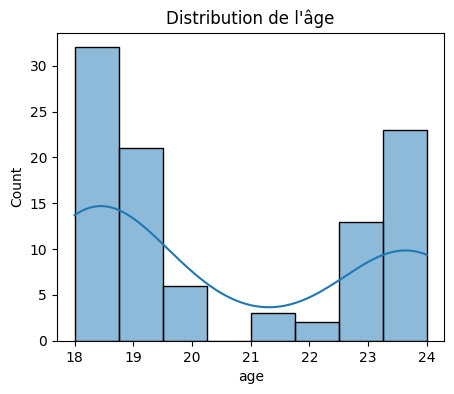

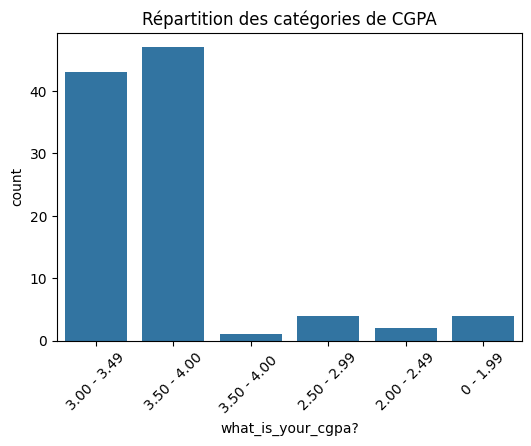

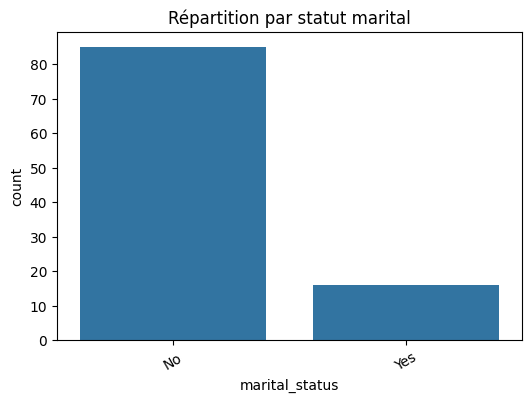

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramme de l'âge
plt.figure(figsize=(5,4))
sns.histplot(data['age'], kde=True)
plt.title("Distribution de l'âge")
plt.show()

# Graphe du CGPA
plt.figure(figsize=(6,4))
sns.countplot(x=data['what_is_your_cgpa?'])
plt.xticks(rotation=45)
plt.title("Répartition des catégories de CGPA")
plt.show()

# Graphe du statut marital
plt.figure(figsize=(6,4))
sns.countplot(x=data['marital_status'])
plt.xticks(rotation=30)
plt.title("Répartition par statut marital")
plt.show()

1. Le deuxième graphique montre la distribution de l’âge des étudiants. On observe surtout deux groupes principaux : un premier autour de **18–19 ans** et un second autour de 23–24 ans. Il y a très peu d’étudiants entre **21 et 22 ans**, ce qui crée une sorte de “creux” au milieu de la distribution.

2. Le graphique montre que la grande majorité des étudiants ont un CGPA compris entre **3.00–3.49** et **3.50–4.00**. Les autres catégories sont très peu représentées. Cela signifie que la plupart des étudiants de l’échantillon ont de bons ou très bons résultats académiques.

3. Pour le dernier graphe, on remarque que la plupart des étudiants sont **célibataires**; les autres statuts sont minoritaires.

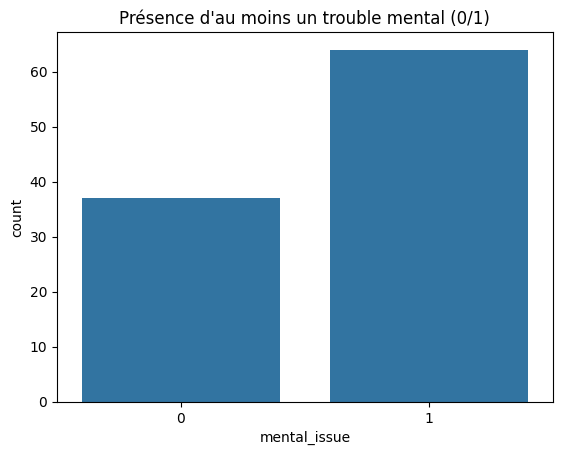

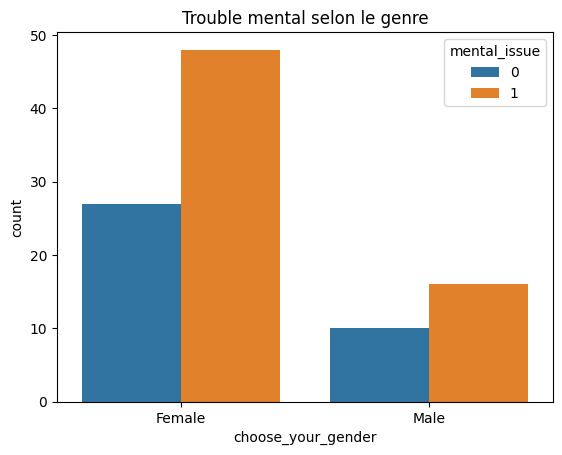

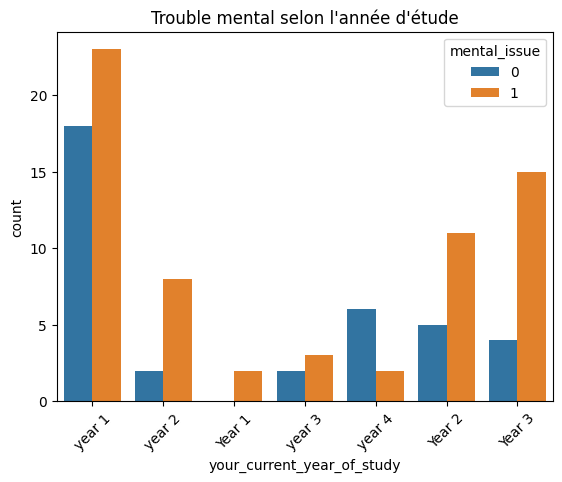

In [14]:
# Répartition de la target
sns.countplot(x=data['mental_issue'])
plt.title("Présence d'au moins un trouble mental (0/1)")
plt.show()

# Trouble mental selon le genre
sns.countplot(x=data['choose_your_gender'], hue=data['mental_issue'])
plt.title("Trouble mental selon le genre")
plt.show()

# Trouble mental selon l'année d'étude
sns.countplot(x=data['your_current_year_of_study'], hue=data['mental_issue'])
plt.title("Trouble mental selon l'année d'étude")
plt.xticks(rotation=45)
plt.show()

1. On voit que les étudiants avec au moins un trouble mental (1) sont plus nombreux que ceux sans trouble (0). Les problèmes de santé mentale sont donc fréquents dans cet échantillon.

2. Chez les deux genres, il y a plus d’étudiants avec trouble que sans. L’écart semble un peu plus fort chez les étudiantes, ce qui peut indiquer plus de cas déclarés chez elles.

3. Dans plusieurs années d’étude, les étudiants avec trouble sont plus nombreux que ceux sans. Les difficultés psychologiques touchent donc différents niveaux, pas une seule année.

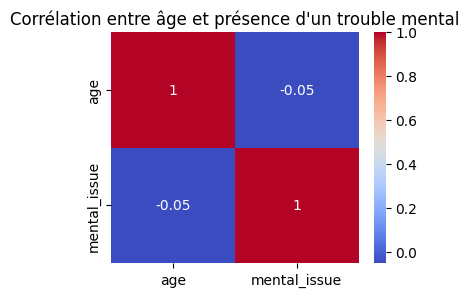

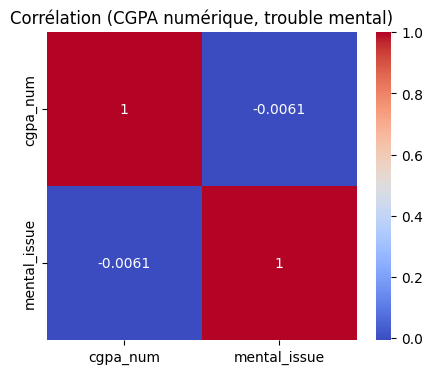

In [18]:
# Heatmap de corrélation âge/mental issue
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,3))
corr = data[['age', 'mental_issue']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Corrélation entre âge et présence d'un trouble mental")
plt.show()

# Heatmap de corrélation CGPA/mental issue
# créer une version numérique approximative du CGPA
mapping_cgpa = {
    '0.00 - 1.99': 1.0,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}

data['cgpa_num'] = data['what_is_your_cgpa?'].map(mapping_cgpa)

# heatmap avec cgpa_num et mental_issue
plt.figure(figsize=(5,4))
corr = data[['cgpa_num', 'mental_issue']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Corrélation (CGPA numérique, trouble mental)")
plt.show()

1. La corrélation entre l’âge et la variable mental_issue est **faible**. Dans ce dataset, l’âge seul n’explique pas fortement la présence d’un trouble mental.

2. Cette heatmap montre la corrélation entre le CGPA numérique et la variable mental_issue. La valeur de corrélation est proche de 0, ce qui indique qu’il n’y a pas de lien linéaire fort entre le niveau de CGPA et la présence d’un trouble mental dans ce dataset.

In [19]:
# Feature Engineering
# Création d'une nouvelle variable simple nommée "senior"
data['is_senior'] = data['your_current_year_of_study'].isin(
    ['3rd year', '4th year', '5th year']
).astype(int)

data[['your_current_year_of_study', 'is_senior']].head()

,your_current_year_of_study,is_senior
0,year 1,0
1,year 2,0
2,Year 1,0
3,year 3,0
4,year 4,0


# **Machine Learning**

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 3 modèles simples
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

# Validation croisée (k-fold) pour comparer
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name} - Accuracy moyenne (CV): {scores.mean():.3f}")

LogisticRegression - Accuracy moyenne (CV): 0.688
RandomForest - Accuracy moyenne (CV): 0.675
KNN - Accuracy moyenne (CV): 0.588


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_rf.best_params_)
print("Meilleure accuracy CV :", grid_rf.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Meilleure accuracy CV : 0.725


Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.12      0.22         8
           1       0.65      1.00      0.79        13

    accuracy                           0.67        21
   macro avg       0.82      0.56      0.51        21
weighted avg       0.78      0.67      0.57        21



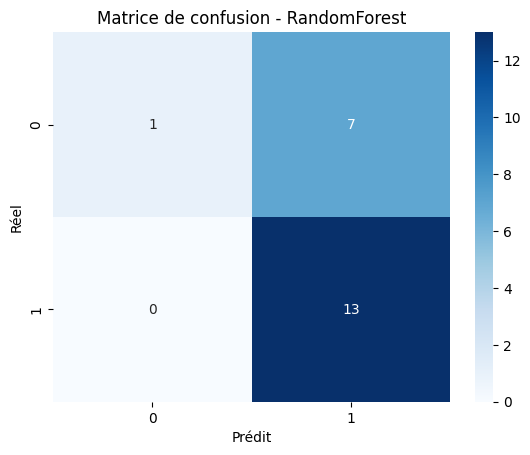

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = grid_rf.best_estimator_

y_pred = best_model.predict(X_test)

print("Rapport de classification :")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - RandomForest")
plt.show()

**Ligne du haut (réel = 0, pas de trouble mental):**
- 1 étudiant sans trouble correctement prédit comme 0.
- 7 étudiants sans trouble prédits à tort comme ayant un trouble (1) → faux positifs.

**Ligne du bas (réel = 1, trouble mental):**
- 13 étudiants avec trouble correctement prédits comme 1.
- 0 étudiants avec trouble prédits à tort comme 0 → pas de faux négatifs.

--> Donc: Le modèle détecte bien presque tous les étudiants avec trouble, mais il “sur‑prédit” la présence de trouble et se trompe souvent sur les étudiants sans trouble


ROC-AUC : 0.6009615384615385


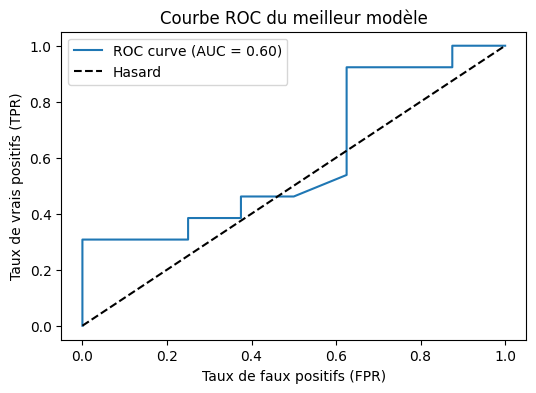

In [23]:
# Courbe ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Prédire les probabilités pour la classe 1 avec ton meilleur modèle
# ici on suppose que ton meilleur modèle s'appelle best_model
y_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Calculer les points de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 3. Calculer l'AUC
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC :", auc)

# 4. Tracer la courbe ROC
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Hasard")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC du meilleur modèle")
plt.legend()
plt.show()

Cette courbe ROC représente la performance du meilleur modèle pour distinguer les étudiants avec et sans trouble mental. L’AUC est d’environ 0,60, ce qui montre une capacité de séparation légèrement meilleure que le hasard, mais encore perfectible.